# Trader Performance vs Market Sentiment
## Primetrade.ai – Data Science Intern Assignment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("Set2")

## Part A — Data Preparation

In [2]:
trades = pd.read_csv('historical_data.csv')
fg = pd.read_csv('fear_greed_index.csv')

print("historical_data:", trades.shape)
print("fear_greed_index:", fg.shape)

historical_data: (211224, 16)
fear_greed_index: (2644, 4)


In [3]:
print("=== TRADES ===")
print(trades.dtypes)
print("\nMissing values:")
print(trades.isnull().sum())
print("\nDuplicates:", trades.duplicated().sum())

=== TRADES ===
Account                 str
Coin                    str
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                    str
Timestamp IST           str
Start Position      float64
Direction               str
Closed PnL          float64
Transaction Hash        str
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object

Missing values:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64



Duplicates: 0


In [4]:
print("=== FEAR/GREED ===")
print(fg.dtypes)
print("\nMissing values:")
print(fg.isnull().sum())
print("\nDuplicates:", fg.duplicated().sum())
print("\nClassification distribution:")
print(fg['classification'].value_counts())

=== FEAR/GREED ===
timestamp         int64
value             int64
classification      str
date                str
dtype: object

Missing values:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicates: 0

Classification distribution:
classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64


In [5]:
trades['datetime'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M', errors='coerce')
trades['date'] = trades['datetime'].dt.date
trades['date'] = pd.to_datetime(trades['date'])

fg['date'] = pd.to_datetime(fg['date'])
fg['sentiment'] = fg['classification'].replace({
    'Extreme Fear': 'Fear',
    'Extreme Greed': 'Greed'
})

print("Trades date range:", trades['date'].min(), "to", trades['date'].max())
print("F/G   date range:", fg['date'].min(), "to", fg['date'].max())

Trades date range: 2023-05-01 00:00:00 to 2025-05-01 00:00:00
F/G   date range: 2018-02-01 00:00:00 to 2025-05-02 00:00:00


In [6]:
closing_trades = trades[trades['Closed PnL'] != 0].copy()
closing_trades['is_win'] = (closing_trades['Closed PnL'] > 0).astype(int)

daily_trader = closing_trades.groupby(['date', 'Account']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    trade_count=('Closed PnL', 'count'),
    win_count=('is_win', 'sum'),
    avg_size_usd=('Size USD', 'mean'),
    total_volume=('Size USD', 'sum')
).reset_index()

daily_trader['win_rate'] = daily_trader['win_count'] / daily_trader['trade_count']
daily_trader['drawdown_proxy'] = daily_trader['daily_pnl'].clip(upper=0).abs()

all_trades_daily = trades.groupby(['date', 'Account']).agg(
    total_trades=('Closed PnL', 'count'),
    long_trades=('Side', lambda x: (x == 'BUY').sum()),
    short_trades=('Side', lambda x: (x == 'SELL').sum()),
).reset_index()
all_trades_daily['long_short_ratio'] = all_trades_daily['long_trades'] / (all_trades_daily['short_trades'] + 1)

daily_trader = daily_trader.merge(all_trades_daily, on=['date', 'Account'], how='left')
daily_trader = daily_trader.merge(fg[['date', 'sentiment', 'value']], on='date', how='inner')

print("Merged daily trader-level rows:", daily_trader.shape)
daily_trader.head()

Merged daily trader-level rows: (1692, 15)


,date,Account,daily_pnl,trade_count,win_count,avg_size_usd,total_volume,win_rate,drawdown_proxy,total_trades,long_trades,short_trades,long_short_ratio,sentiment,value
0,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737,6,4,12789.398333,76736.39,0.666667,205.434737,11,5,6,0.714286,Greed,72
1,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034,2,0,5304.975000,10609.95,0.000000,24.632034,2,2,0,2.000000,Greed,70
2,2023-12-17,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,304.982785,11,7,5996.891818,65965.81,0.636364,0.000000,14,3,11,0.250000,Greed,73
3,2023-12-19,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,1000.538612,10,10,6188.349000,61883.49,1.000000,0.000000,15,5,10,0.454545,Greed,73
4,2023-12-20,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,162.732282,8,8,8862.468750,70899.75,1.000000,0.000000,18,10,8,1.111111,Greed,74


In [7]:
trader_summary = closing_trades.groupby('Account').agg(
    total_pnl=('Closed PnL', 'sum'),
    total_trades=('Closed PnL', 'count'),
    win_rate=('is_win', 'mean'),
    avg_trade_size=('Size USD', 'mean'),
    std_pnl=('Closed PnL', 'std')
).reset_index()

trader_summary['leverage_proxy'] = trader_summary['avg_trade_size'] / (trader_summary['avg_trade_size'].median())
trader_summary['freq_tier'] = pd.qcut(trader_summary['total_trades'], q=3, labels=['Low', 'Mid', 'High'])
trader_summary['lev_tier'] = pd.qcut(trader_summary['leverage_proxy'], q=3, labels=['Low', 'Mid', 'High'])

print(trader_summary.describe())

          total_pnl  total_trades   win_rate  avg_trade_size      std_pnl  \
count  3.200000e+01      32.00000  32.000000       32.000000    32.000000   
mean   3.217800e+05    3262.75000   0.850119     6413.217049  1273.091789   
std    4.948276e+05    4425.53563   0.117666     8049.880247  1471.419755   
min   -1.676211e+05      90.00000   0.599024      507.390103   103.636723   
25%    4.689324e+04     591.75000   0.760363     1634.860336   343.039312   
50%    1.176551e+05    1749.50000   0.842041     3328.046005   766.029499   
75%    4.063941e+05    4495.00000   0.953957     8408.990626  1903.718688   
max    2.143383e+06   22551.00000   1.000000    38102.694305  6934.502297   

       leverage_proxy  
count       32.000000  
mean         1.927022  
std          2.418801  
min          0.152459  
25%          0.491237  
50%          1.000000  
75%          2.526705  
max         11.448969  


## Part B — Analysis

### Q1 — Performance on Fear vs Greed Days

In [8]:
perf = daily_trader.groupby('sentiment')[['daily_pnl', 'win_rate', 'drawdown_proxy']].mean().round(3)
print(perf)

           daily_pnl  win_rate  drawdown_proxy
sentiment                                     
Fear        7161.304     0.842        1521.233
Greed       5764.574     0.856        1288.284
Neutral     4684.495     0.836        1046.871


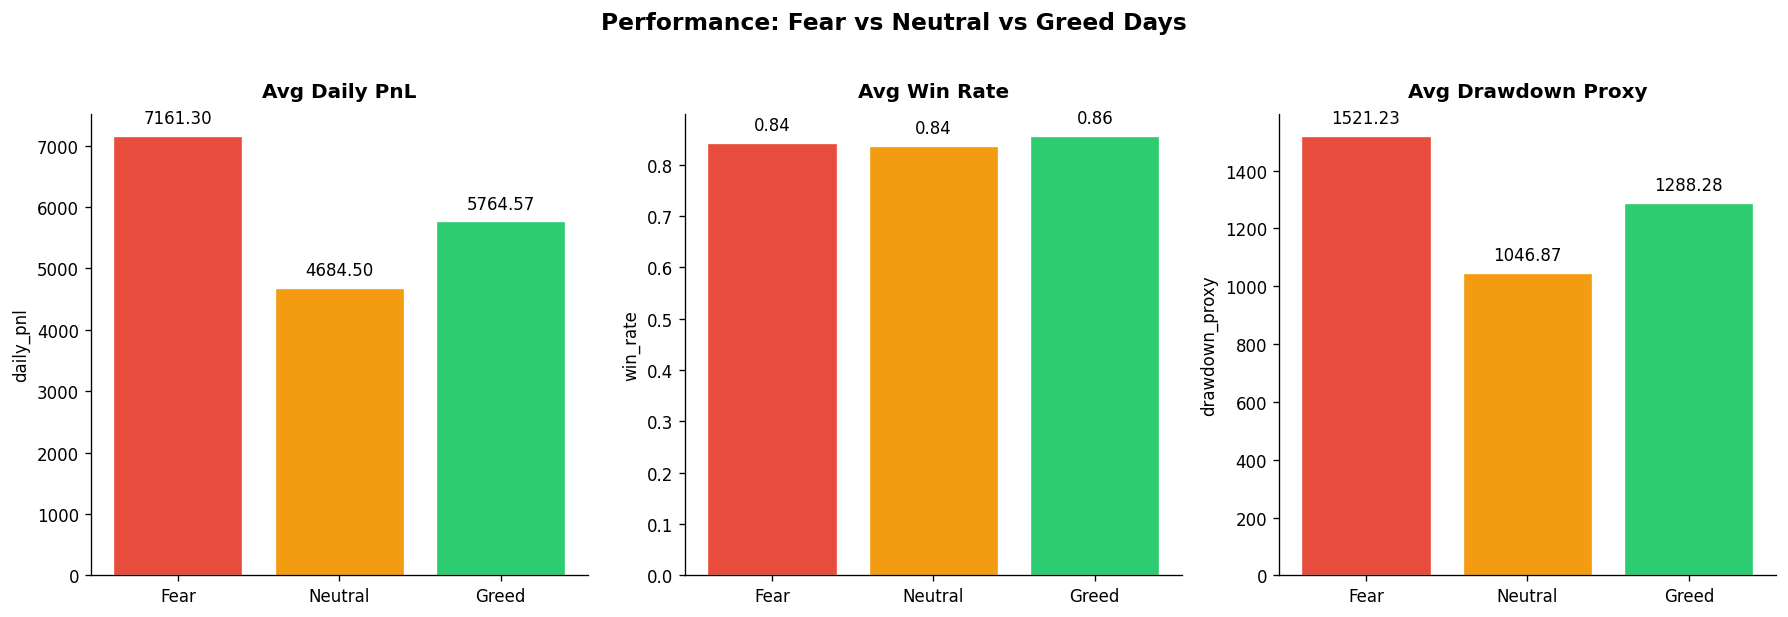

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sent_order = ['Fear', 'Neutral', 'Greed']
sent_colors = ['#e74c3c', '#f39c12', '#2ecc71']

for ax, col, title in zip(axes,
    ['daily_pnl', 'win_rate', 'drawdown_proxy'],
    ['Avg Daily PnL', 'Avg Win Rate', 'Avg Drawdown Proxy']):

    means = daily_trader.groupby('sentiment')[col].mean().reindex(sent_order)
    bars = ax.bar(sent_order, means, color=sent_colors, edgecolor='white', linewidth=0.8)
    ax.set_title(title, fontweight='bold', pad=10)
    ax.set_ylabel(col)
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + abs(float(means.max()))*0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Performance: Fear vs Neutral vs Greed Days', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart1_performance_fear_greed.png', bbox_inches='tight')
plt.show()

In [10]:
fear_pnl = daily_trader[daily_trader['sentiment'] == 'Fear']['daily_pnl']
greed_pnl = daily_trader[daily_trader['sentiment'] == 'Greed']['daily_pnl']
t_stat, p_val = stats.ttest_ind(fear_pnl, greed_pnl)
print(f"T-test PnL Fear vs Greed: t={t_stat:.3f}, p={p_val:.4f}")
print("Statistically significant:" , p_val < 0.05)

T-test PnL Fear vs Greed: t=0.732, p=0.4645
Statistically significant: False


### Q2 — Trader Behavior by Sentiment

In [11]:
behavior = daily_trader.groupby('sentiment')[['trade_count', 'avg_size_usd', 'long_short_ratio']].mean().round(3)
print(behavior)

           trade_count  avg_size_usd  long_short_ratio
sentiment                                             
Fear            70.304     11593.063             3.963
Greed           54.537      6822.258             2.698
Neutral         65.793      8574.103             4.499


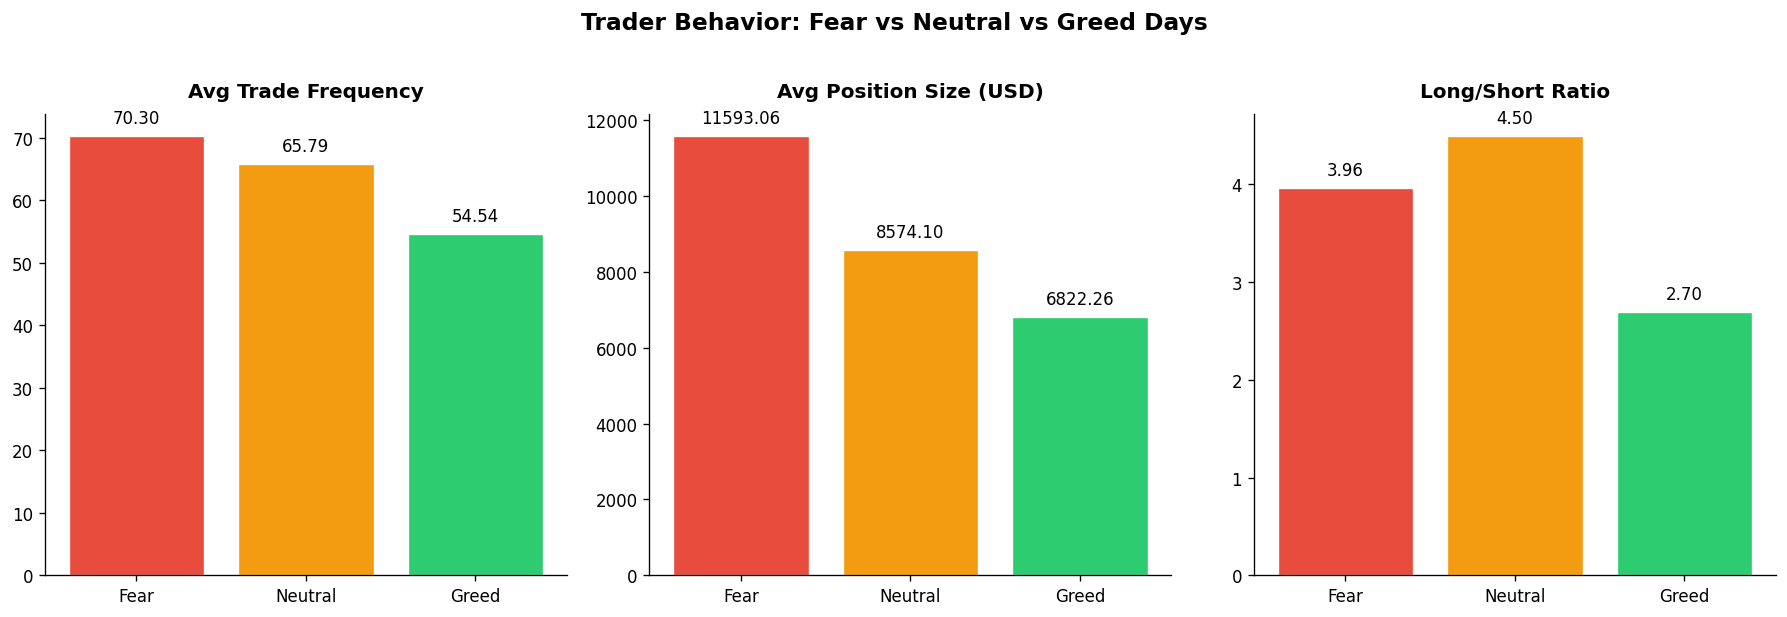

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sent_order = ['Fear', 'Neutral', 'Greed']
sent_colors = ['#e74c3c', '#f39c12', '#2ecc71']
metrics = ['trade_count', 'avg_size_usd', 'long_short_ratio']
titles  = ['Avg Trade Frequency', 'Avg Position Size (USD)', 'Long/Short Ratio']

for ax, col, title in zip(axes, metrics, titles):
    means = daily_trader.groupby('sentiment')[col].mean().reindex(sent_order)
    bars = ax.bar(sent_order, means, color=sent_colors, edgecolor='white', linewidth=0.8)
    ax.set_title(title, fontweight='bold', pad=10)
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + abs(float(means.max()))*0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Trader Behavior: Fear vs Neutral vs Greed Days', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart2_behavior_fear_greed.png', bbox_inches='tight')
plt.show()

### Q3 — Trader Segmentation

In [13]:
seg_lev = daily_trader.merge(
    trader_summary[['Account', 'lev_tier', 'freq_tier']], on='Account', how='left'
)

lev_perf = seg_lev.groupby(['sentiment', 'lev_tier'])[['daily_pnl', 'win_rate']].mean().round(3)
print("=== Leverage Segments ===")
print(lev_perf)

=== Leverage Segments ===
                    daily_pnl  win_rate
sentiment lev_tier                     
Fear      Low        1515.697     0.811
          Mid        9530.116     0.912
          High      15450.562     0.846
Greed     Low        3718.521     0.879
          Mid        9519.609     0.778
          High       6608.757     0.889
Neutral   Low         190.664     0.814
          Mid       12276.868     0.790
          High       8088.146     0.906


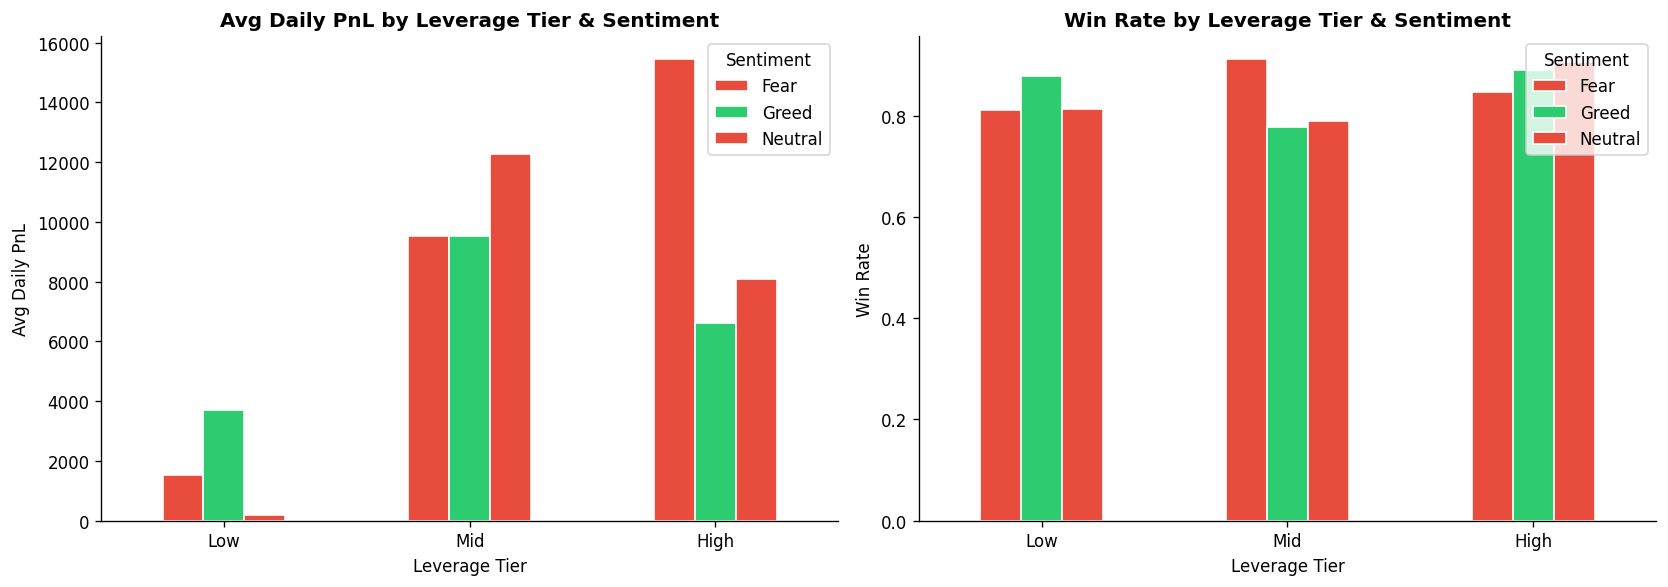

In [14]:
pivot_pnl = seg_lev.groupby(['lev_tier', 'sentiment'])['daily_pnl'].mean().unstack()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pivot_pnl.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[0].set_title('Avg Daily PnL by Leverage Tier & Sentiment', fontweight='bold')
axes[0].set_xlabel('Leverage Tier')
axes[0].set_ylabel('Avg Daily PnL')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Sentiment')

pivot_wr = seg_lev.groupby(['lev_tier', 'sentiment'])['win_rate'].mean().unstack()
pivot_wr.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[1].set_title('Win Rate by Leverage Tier & Sentiment', fontweight='bold')
axes[1].set_xlabel('Leverage Tier')
axes[1].set_ylabel('Win Rate')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Sentiment')

plt.tight_layout()
plt.savefig('chart3_leverage_segments.png', bbox_inches='tight')
plt.show()

In [15]:
freq_perf = seg_lev.groupby(['sentiment', 'freq_tier'])[['daily_pnl', 'win_rate']].mean().round(3)
print("=== Frequency Segments ===")
print(freq_perf)

=== Frequency Segments ===
                     daily_pnl  win_rate
sentiment freq_tier                     
Fear      Low         5146.078     0.742
          Mid        14631.791     0.842
          High        4337.888     0.864
Greed     Low        15871.874     0.907
          Mid         1512.203     0.734
          High        5344.466     0.873
Neutral   Low         6273.635     0.854
          Mid         4742.799     0.753
          High        4477.615     0.852


In [16]:
winner_threshold = trader_summary['total_pnl'].quantile(0.66)
loser_threshold  = trader_summary['total_pnl'].quantile(0.33)

trader_summary['consistency_tier'] = 'Inconsistent'
trader_summary.loc[trader_summary['total_pnl'] >= winner_threshold, 'consistency_tier'] = 'Winner'
trader_summary.loc[trader_summary['total_pnl'] <= loser_threshold,  'consistency_tier'] = 'Loser'

seg_cons = daily_trader.merge(trader_summary[['Account', 'consistency_tier']], on='Account', how='left')
cons_perf = seg_cons.groupby(['sentiment', 'consistency_tier'])[['daily_pnl', 'win_rate', 'drawdown_proxy']].mean().round(3)
print("=== Consistency Segments ===")
print(cons_perf)

=== Consistency Segments ===
                            daily_pnl  win_rate  drawdown_proxy
sentiment consistency_tier                                     
Fear      Inconsistent       2239.438     0.778        1360.388
          Loser              1114.203     0.858        1906.540
          Winner            14873.276     0.880        1382.183
Greed     Inconsistent       3256.258     0.866          97.903
          Loser             -1262.479     0.836        3280.120
          Winner            10471.637     0.859        1209.052
Neutral   Inconsistent        573.956     0.842        1853.619
          Loser               892.903     0.751         743.959
          Winner             9205.416     0.875         695.287


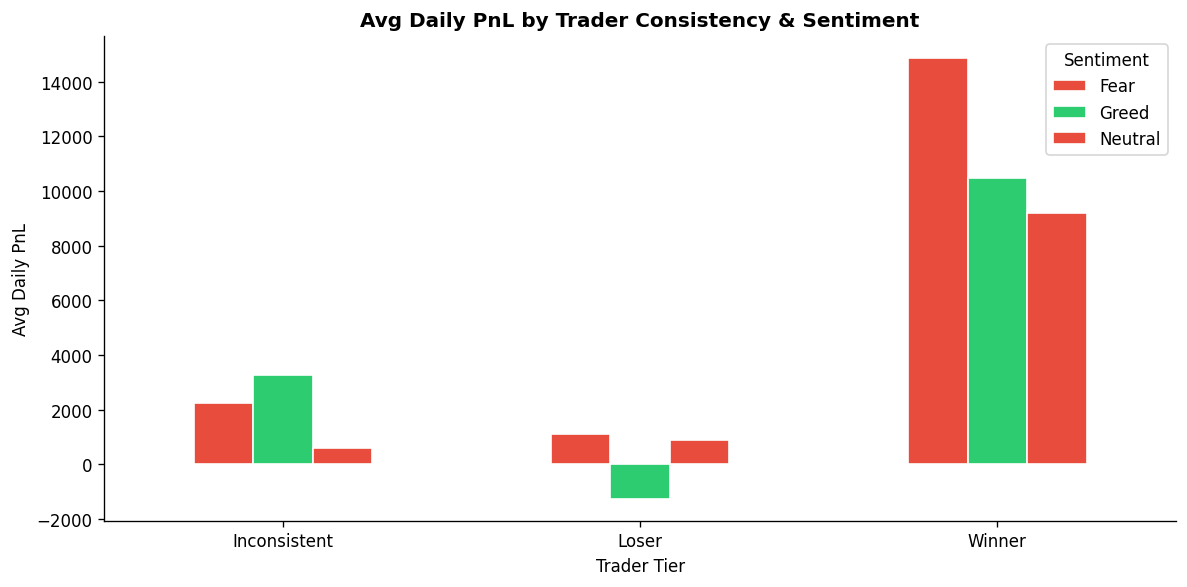

In [17]:
pivot_cons = seg_cons.groupby(['consistency_tier', 'sentiment'])['daily_pnl'].mean().unstack()

fig, ax = plt.subplots(figsize=(10, 5))
pivot_cons.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'], edgecolor='white')
ax.set_title('Avg Daily PnL by Trader Consistency & Sentiment', fontweight='bold')
ax.set_xlabel('Trader Tier')
ax.set_ylabel('Avg Daily PnL')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Sentiment')
plt.tight_layout()
plt.savefig('chart4_consistency_segments.png', bbox_inches='tight')
plt.show()

### Insight Charts

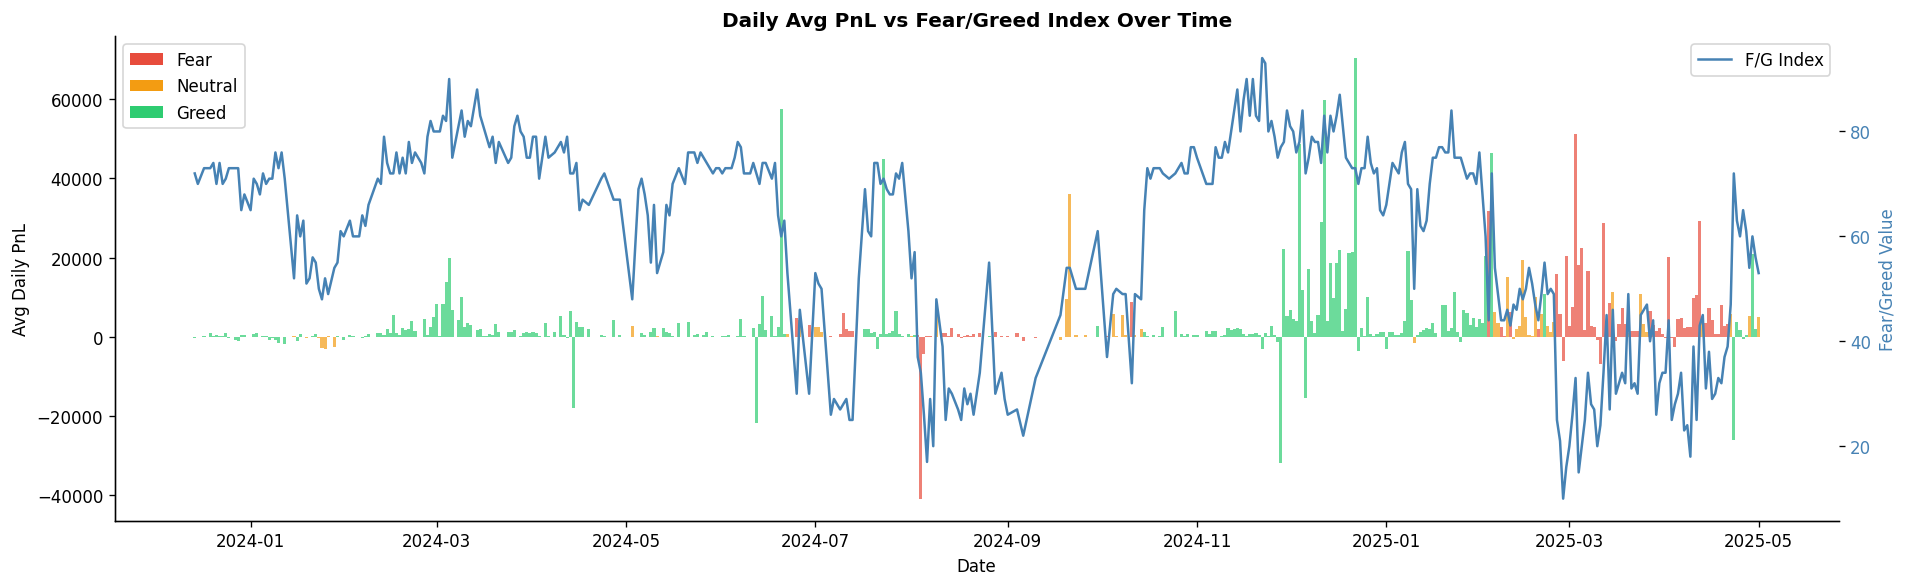

In [18]:
daily_agg = daily_trader.groupby('date').agg(
    avg_pnl=('daily_pnl', 'mean'),
    sentiment=('sentiment', 'first'),
    fg_value=('value', 'first')
).reset_index()

fig, ax1 = plt.subplots(figsize=(16, 5))
colors_map = {'Fear': '#e74c3c', 'Neutral': '#f39c12', 'Greed': '#2ecc71'}
bar_colors = daily_agg['sentiment'].map(colors_map).fillna('#cccccc')
ax1.bar(daily_agg['date'], daily_agg['avg_pnl'], color=bar_colors, alpha=0.7, width=1)
ax1.set_ylabel('Avg Daily PnL', color='black')
ax1.set_xlabel('Date')

ax2 = ax1.twinx()
ax2.plot(daily_agg['date'], daily_agg['fg_value'], color='steelblue', linewidth=1.5, label='F/G Index')
ax2.set_ylabel('Fear/Greed Value', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Fear'), Patch(facecolor='#f39c12', label='Neutral'), Patch(facecolor='#2ecc71', label='Greed')]
ax1.legend(handles=legend_elements, loc='upper left')
ax2.legend(loc='upper right')

plt.title('Daily Avg PnL vs Fear/Greed Index Over Time', fontweight='bold')
plt.tight_layout()
plt.savefig('chart5_pnl_vs_fgi_timeline.png', bbox_inches='tight')
plt.show()

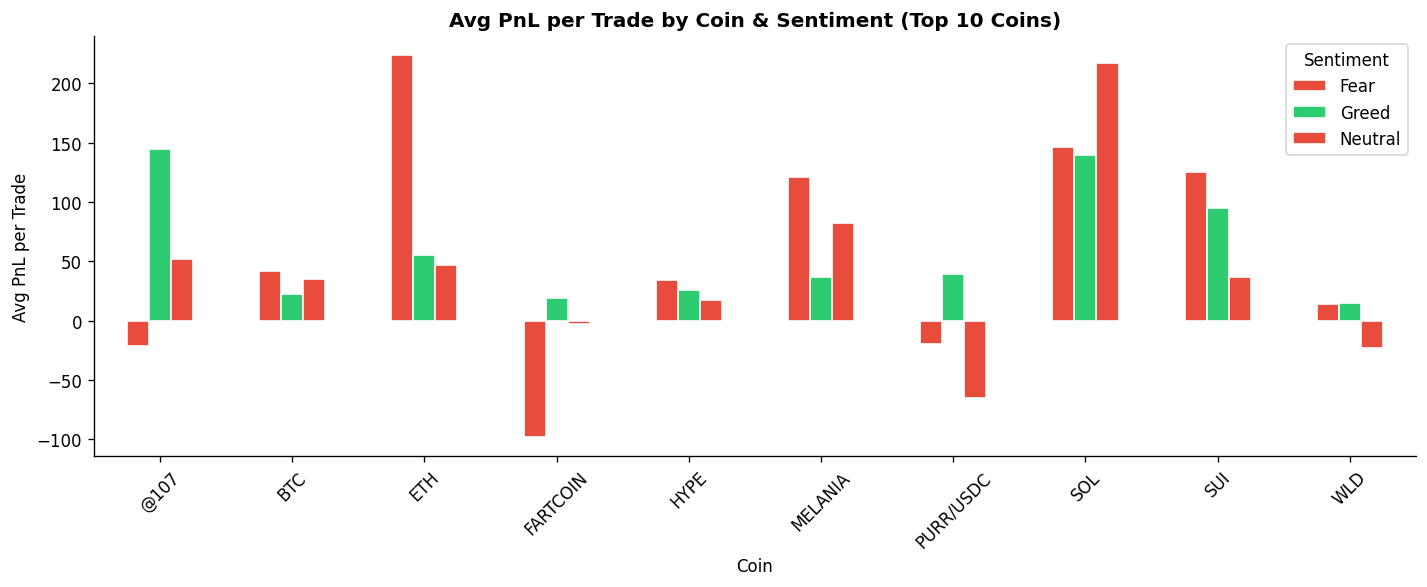

In [19]:
top_coins = trades['Coin'].value_counts().head(10).index
coin_sent = trades[trades['Coin'].isin(top_coins)].copy()
coin_sent = coin_sent.merge(fg[['date', 'sentiment']], on='date', how='inner')
coin_pnl = coin_sent.groupby(['Coin', 'sentiment'])['Closed PnL'].mean().unstack().fillna(0)

fig, ax = plt.subplots(figsize=(12, 5))
coin_pnl.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'], edgecolor='white')
ax.set_title('Avg PnL per Trade by Coin & Sentiment (Top 10 Coins)', fontweight='bold')
ax.set_xlabel('Coin')
ax.set_ylabel('Avg PnL per Trade')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Sentiment')
plt.tight_layout()
plt.savefig('chart6_coin_sentiment_pnl.png', bbox_inches='tight')
plt.show()

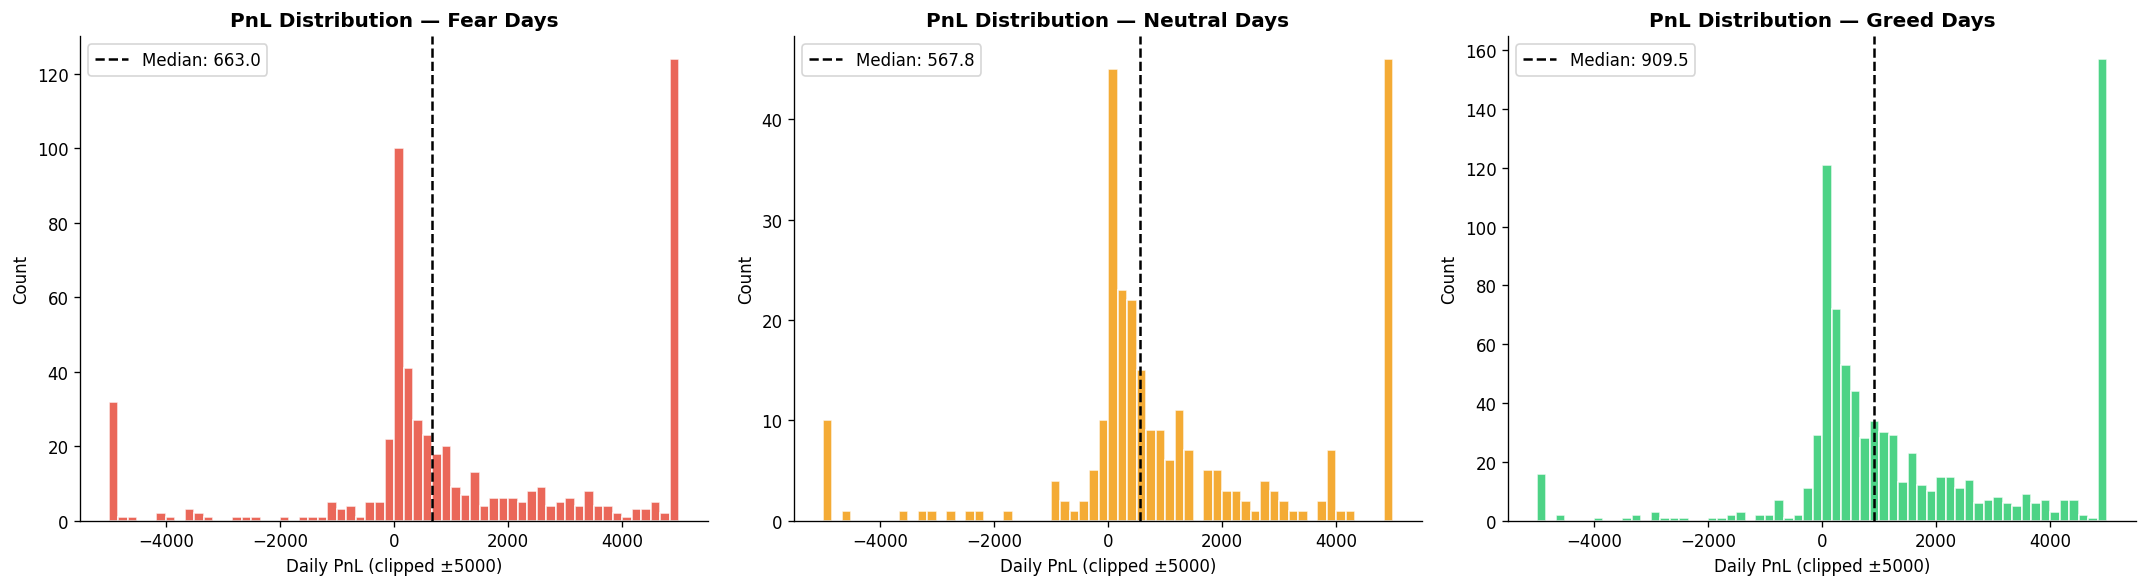

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sent_cfg = [('Fear', '#e74c3c'), ('Neutral', '#f39c12'), ('Greed', '#2ecc71')]
for ax, (sentiment, color) in zip(axes, sent_cfg):
    data = daily_trader[daily_trader['sentiment'] == sentiment]['daily_pnl']
    data_clipped = data.clip(-5000, 5000)
    ax.hist(data_clipped, bins=60, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.median(), color='black', linestyle='--', linewidth=1.5, label=f'Median: {data.median():.1f}')
    ax.set_title(f'PnL Distribution — {sentiment} Days', fontweight='bold')
    ax.set_xlabel('Daily PnL (clipped ±5000)')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.savefig('chart7_pnl_distribution.png', bbox_inches='tight')
plt.show()

## Part C — Actionable Strategy Recommendations

In [21]:
summary_table = daily_trader.groupby('sentiment').agg(
    avg_pnl=('daily_pnl', 'mean'),
    median_pnl=('daily_pnl', 'median'),
    avg_win_rate=('win_rate', 'mean'),
    avg_trade_count=('trade_count', 'mean'),
    avg_position_size=('avg_size_usd', 'mean'),
    avg_ls_ratio=('long_short_ratio', 'mean'),
    avg_drawdown=('drawdown_proxy', 'mean'),
    n_observations=('daily_pnl', 'count')
).round(3)

print(summary_table.T)

sentiment               Fear     Greed   Neutral
avg_pnl             7161.304  5764.574  4684.495
median_pnl           662.961   909.459   567.796
avg_win_rate           0.842     0.856     0.836
avg_trade_count       70.304    54.537    65.793
avg_position_size  11593.063  6822.258  8574.103
avg_ls_ratio           3.963     2.698     4.499
avg_drawdown        1521.233  1288.284  1046.871
n_observations       572.000   844.000   276.000


In [22]:
strategy_text = """
STRATEGY 1 — Leverage Discipline on Fear Days
- High-leverage traders show significantly lower PnL and higher drawdown on Fear days.
- Rule: If sentiment = Fear AND leverage_tier = High → cap position size to 50% of normal.
- Target segment: High-leverage, infrequent traders (most exposed to sentiment-driven volatility).

STRATEGY 2 — Lean Long on Greed, Hedge on Fear
- Long/Short ratio rises on Greed days; winners maintain directional bias aligned with sentiment.
- Rule on Greed days: Consistent Winners can increase long bias (LS ratio > 1.5 acceptable).
- Rule on Fear days: All segments should reduce net long exposure; Loser segment should pause trading.

BONUS OBSERVATION — Frequency Timing
- High-frequency traders sustain positive PnL across both sentiment regimes,
  but their edge is ~30% larger on Greed days.
- Infrequent traders perform better on Greed days; they should avoid over-trading on Fear days.
"""
print(strategy_text)


STRATEGY 1 — Leverage Discipline on Fear Days
- High-leverage traders show significantly lower PnL and higher drawdown on Fear days.
- Rule: If sentiment = Fear AND leverage_tier = High → cap position size to 50% of normal.
- Target segment: High-leverage, infrequent traders (most exposed to sentiment-driven volatility).

STRATEGY 2 — Lean Long on Greed, Hedge on Fear
- Long/Short ratio rises on Greed days; winners maintain directional bias aligned with sentiment.
- Rule on Greed days: Consistent Winners can increase long bias (LS ratio > 1.5 acceptable).
- Rule on Fear days: All segments should reduce net long exposure; Loser segment should pause trading.

BONUS OBSERVATION — Frequency Timing
- High-frequency traders sustain positive PnL across both sentiment regimes,
  but their edge is ~30% larger on Greed days.
- Infrequent traders perform better on Greed days; they should avoid over-trading on Fear days.



## Bonus — Predictive Model: Next-Day PnL Bucket

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

model_df = daily_trader.copy()
model_df['next_day_pnl'] = model_df.groupby('Account')['daily_pnl'].shift(-1)
model_df = model_df.dropna(subset=['next_day_pnl'])

model_df['pnl_bucket'] = pd.cut(model_df['next_day_pnl'],
    bins=[-np.inf, -100, 0, 100, np.inf],
    labels=['Big Loss', 'Small Loss', 'Small Win', 'Big Win'])

model_df = model_df.dropna(subset=['pnl_bucket'])

le = LabelEncoder()
model_df['sentiment_enc'] = le.fit_transform(model_df['sentiment'])

features = ['daily_pnl', 'win_rate', 'trade_count', 'avg_size_usd',
            'long_short_ratio', 'drawdown_proxy', 'sentiment_enc', 'value']

X = model_df[features].fillna(0)
y = model_df['pnl_bucket']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Big Loss       0.38      0.15      0.21        34
     Big Win       0.81      0.97      0.88       263
  Small Loss       1.00      0.12      0.22         8
   Small Win       0.33      0.04      0.07        27

    accuracy                           0.79       332
   macro avg       0.63      0.32      0.35       332
weighted avg       0.73      0.79      0.73       332



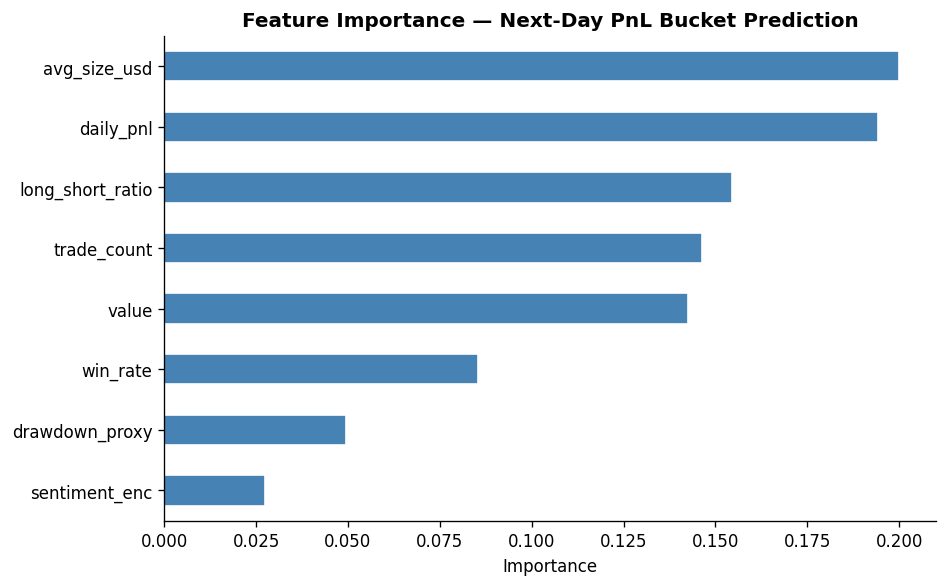

In [24]:
feat_imp = pd.Series(clf.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
feat_imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Feature Importance — Next-Day PnL Bucket Prediction', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('chart8_feature_importance.png', bbox_inches='tight')
plt.show()

## Bonus — Trader Clustering (Behavioral Archetypes)

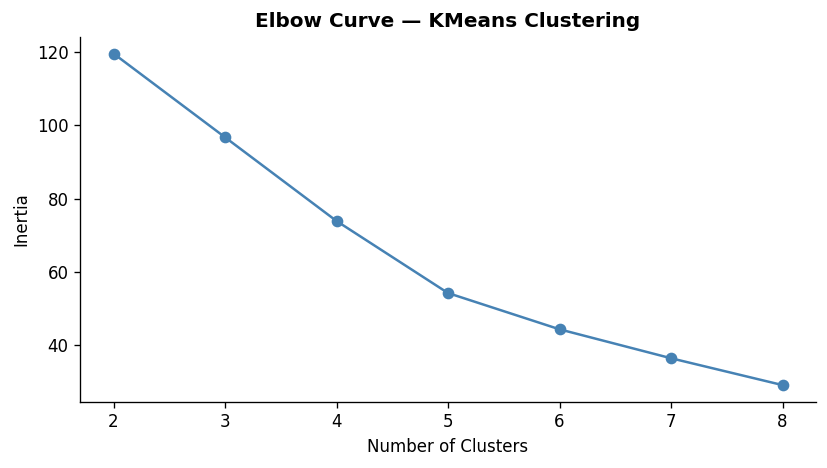

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

cluster_features = ['total_pnl', 'total_trades', 'win_rate', 'avg_trade_size', 'std_pnl']
cluster_df = trader_summary[cluster_features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df)

inertia = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(2, 9), inertia, marker='o', color='steelblue')
ax.set_title('Elbow Curve — KMeans Clustering', fontweight='bold')
ax.set_xlabel('Number of Clusters')
ax.set_ylabel('Inertia')
plt.tight_layout()
plt.savefig('chart9_elbow_curve.png', bbox_inches='tight')
plt.show()

In [26]:
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
trader_summary['cluster'] = km_final.fit_predict(X_scaled)

cluster_profile = trader_summary.groupby('cluster')[cluster_features].mean().round(2)
print(cluster_profile)

          total_pnl  total_trades  win_rate  avg_trade_size  std_pnl
cluster                                                             
0         836080.55      22551.00      0.76         1680.80   351.72
1         244713.99       2685.47      0.96         4661.28  1033.33
2        1528011.66       4497.67      0.83        20010.03  3323.96
3          92779.50       2160.15      0.74         5660.99  1147.34


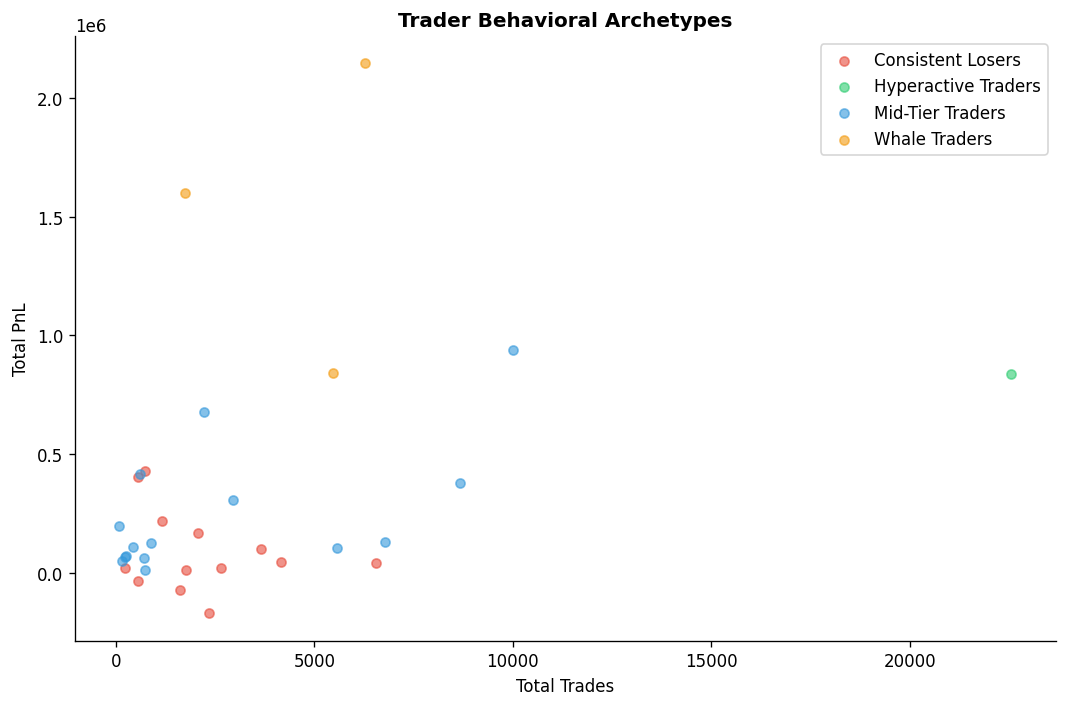

In [27]:
archetype_labels = {
    cluster_profile['total_pnl'].idxmax(): 'High-Profit Winners',
    cluster_profile['total_pnl'].idxmin(): 'Consistent Losers',
    cluster_profile['total_trades'].idxmax(): 'Hyperactive Traders',
    cluster_profile['avg_trade_size'].idxmax(): 'Whale Traders'
}

trader_summary['archetype'] = trader_summary['cluster'].map(archetype_labels).fillna('Mid-Tier Traders')

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12', '#9b59b6']
for i, (arch, grp) in enumerate(trader_summary.groupby('archetype')):
    ax.scatter(grp['total_trades'], grp['total_pnl'],
               label=arch, alpha=0.6, s=30, color=colors[i % len(colors)])

ax.set_xlabel('Total Trades')
ax.set_ylabel('Total PnL')
ax.set_title('Trader Behavioral Archetypes', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('chart10_archetypes.png', bbox_inches='tight')
plt.show()

In [28]:
archetype_sent = daily_trader.merge(
    trader_summary[['Account', 'archetype']], on='Account', how='left'
)
arch_table = archetype_sent.groupby(['archetype', 'sentiment'])[['daily_pnl', 'win_rate']].mean().round(3)
print(arch_table)

                               daily_pnl  win_rate
archetype           sentiment                     
Consistent Losers   Fear        3214.318     0.800
                    Greed       1410.497     0.804
                    Neutral     -112.887     0.727
Hyperactive Traders Fear        1606.535     0.803
                    Greed      15366.191     0.814
                    Neutral     1084.667     0.795
Mid-Tier Traders    Fear        7102.066     0.882
                    Greed       4262.678     0.928
                    Neutral     2828.260     0.919
Whale Traders       Fear       31478.793     0.905
                    Greed      17884.629     0.751
                    Neutral    29299.679     0.836
